# Car Price Exploratory Data Analysis

## European vehicle listings and price drivers

This notebook develops a modeling-oriented understanding of the vehicle-listing dataset.
It emphasizes reproducibility, robust visual summaries, target leakage prevention, and
clear conclusions that can guide the first price-prediction model.

**Analysis sequence**

1. Load a focused set of useful columns from the large raw CSV.
2. Validate data quality and engineer interpretable EDA features.
3. Analyze price, mileage, age, make, body type, fuel type, transmission, and geography.
4. Inspect correlations, outliers, and potential target leakage.
5. Convert the findings into concrete modeling decisions.


## 1. Setup and visual design


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data" / "raw" / "cars.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/raw/cars.csv from the current directory.")


PROJECT_ROOT = find_project_root()
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "cars.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "ink": "#172238",
    "blue": "#226F92",
    "teal": "#2A9D8F",
    "coral": "#E76F51",
    "gold": "#E9C46A",
    "cream": "#F7F3EA",
    "muted": "#718096",
    "grid": "#D9DEE8",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.facecolor": COLORS["cream"],
        "axes.facecolor": COLORS["cream"],
        "axes.edgecolor": COLORS["ink"],
        "axes.labelcolor": COLORS["ink"],
        "axes.titlecolor": COLORS["ink"],
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "grid.color": COLORS["grid"],
        "grid.alpha": 0.7,
        "text.color": COLORS["ink"],
        "xtick.color": COLORS["ink"],
        "ytick.color": COLORS["ink"],
    }
)

currency = FuncFormatter(lambda value, _: f"€{value:,.0f}")


def finish_figure(fig, filename: str) -> None:
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / filename,
        dpi=180,
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
    )
    plt.show()


print(f"Dataset: {CSV_PATH}")
print(f"File size: {CSV_PATH.stat().st_size / (1024 ** 2):,.1f} MB")
print(f"Figures: {FIGURE_DIR}")


Dataset: C:\Users\tuomas.kuusisto_cens\projects\car-price-prediction\data\raw\cars.csv
File size: 523.2 MB
Figures: C:\Users\tuomas.kuusisto_cens\projects\car-price-prediction\reports\figures


## 2. Load the analysis dataset

The raw file contains long descriptions and equipment lists. Those fields are useful for
future text feature engineering, but reading them now would consume memory without helping
the first tabular EDA. We load only columns that can explain price or reveal data-quality risks.


In [2]:
ANALYSIS_COLUMNS = [
    "id",
    "price",
    "price_net",
    "price_currency",
    "price_tax_deductible",
    "price_vat_rate",
    "original_market",
    "make",
    "model",
    "model_version",
    "mileage_km_raw",
    "registration_date",
    "production_year",
    "vehicle_type",
    "body_type",
    "nr_seats",
    "nr_doors",
    "body_color",
    "paint_type",
    "power_kw",
    "power_hp",
    "transmission",
    "gears",
    "drive_train",
    "cylinders",
    "cylinders_volume_cc",
    "weight_kg",
    "fuel_category",
    "primary_fuel",
    "electric_range_km",
    "fuel_cons_comb_l100_km",
    "co2_emission_grper_km",
    "fuel_cons_comb_l100_wltp_km",
    "co2_emission_grper_wltp_km",
    "is_used",
    "is_new",
    "is_preregistered",
    "had_accident",
    "has_full_service_history",
    "non_smoking",
    "nr_prev_owners",
    "is_rental",
    "envir_standard",
    "offer_type",
    "country_code",
    "seller_is_dealer",
    "seller_type",
]

available_columns = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
missing_requested_columns = sorted(set(ANALYSIS_COLUMNS) - set(available_columns))
if missing_requested_columns:
    raise ValueError(f"Columns not found in the CSV: {missing_requested_columns}")

df = pd.read_csv(CSV_PATH, usecols=ANALYSIS_COLUMNS, low_memory=False)

print(f"Loaded {len(df):,} rows and {df.shape[1]} analysis columns.")
display(df.head(3))


Loaded 118,382 rows and 47 analysis columns.


,id,price_currency,price,price_tax_deductible,price_net,price_vat_rate,make,model,model_version,mileage_km_raw,...,has_full_service_history,non_smoking,nr_prev_owners,is_rental,envir_standard,original_market,offer_type,country_code,seller_is_dealer,seller_type
0,001c08bb-96f9-4198-a2c9-39bcab088a08,EUR,22950.0,True,19279.0,NaN,Suzuki,Swift,1.2 Style Smart Hybrid | Navigatie | Cruise co...,10500.0,...,False,False,NaN,False,Euro 6d-TEMP,NaN,U,NL,True,Dealer
1,00918c06-f736-404a-b55a-0ccd1d876129,EUR,46000.0,False,NaN,NaN,BMW,X3 M,M40i xDrive | nahezu Vollausstattung | Top-Zus...,55609.0,...,True,True,2.0,False,Euro 6d-TEMP,NaN,U,DE,False,PrivateSeller
2,0083e29f-8030-4478-b662-6dff92e22a06,EUR,179900.0,False,NaN,NaN,Porsche,991,.2 GT3 TOURING / MANUAL / CHRONO / LIFT / BOSE,18200.0,...,True,True,NaN,False,Euro 6,NaN,U,BE,True,Dealer


## 3. Data preparation and validation


In [3]:
# Keep the raw columns intact and add clean, analysis-friendly features.
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["registration_year"] = df["registration_date"].dt.year

current_year = pd.Timestamp.today().year
df["vehicle_age"] = current_year - df["registration_year"]
df.loc[~df["vehicle_age"].between(0, 80), "vehicle_age"] = np.nan

df["weight_kg_numeric"] = pd.to_numeric(
    df["weight_kg"].astype("string").str.extract(r"([\d,.]+)", expand=False)
    .str.replace(",", "", regex=False),
    errors="coerce",
)

numeric_cleaning_columns = [
    "price",
    "price_net",
    "mileage_km_raw",
    "production_year",
    "power_kw",
    "power_hp",
    "cylinders_volume_cc",
    "electric_range_km",
    "fuel_cons_comb_l100_km",
    "co2_emission_grper_km",
    "fuel_cons_comb_l100_wltp_km",
    "co2_emission_grper_wltp_km",
]
for column in numeric_cleaning_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

quality_checks = pd.DataFrame(
    {
        "check": [
            "Rows",
            "Columns loaded",
            "Duplicate listing IDs",
            "Missing prices",
            "Non-positive prices",
            "Missing mileage",
            "Missing registration date",
            "Future or implausible vehicle age",
        ],
        "value": [
            len(df),
            df.shape[1],
            df["id"].duplicated().sum(),
            df["price"].isna().sum(),
            df["price"].le(0).sum(),
            df["mileage_km_raw"].isna().sum(),
            df["registration_date"].isna().sum(),
            (current_year - df["registration_year"]).notna().sum()
            - df["vehicle_age"].notna().sum(),
        ],
    }
)

display(quality_checks.style.format({"value": "{:,.0f}"}))


,check,value
0,Rows,"118,382"
1,Columns loaded,50
2,Duplicate listing IDs,0
3,Missing prices,0
4,Non-positive prices,0
5,Missing mileage,644
6,Missing registration date,221
7,Future or implausible vehicle age,7


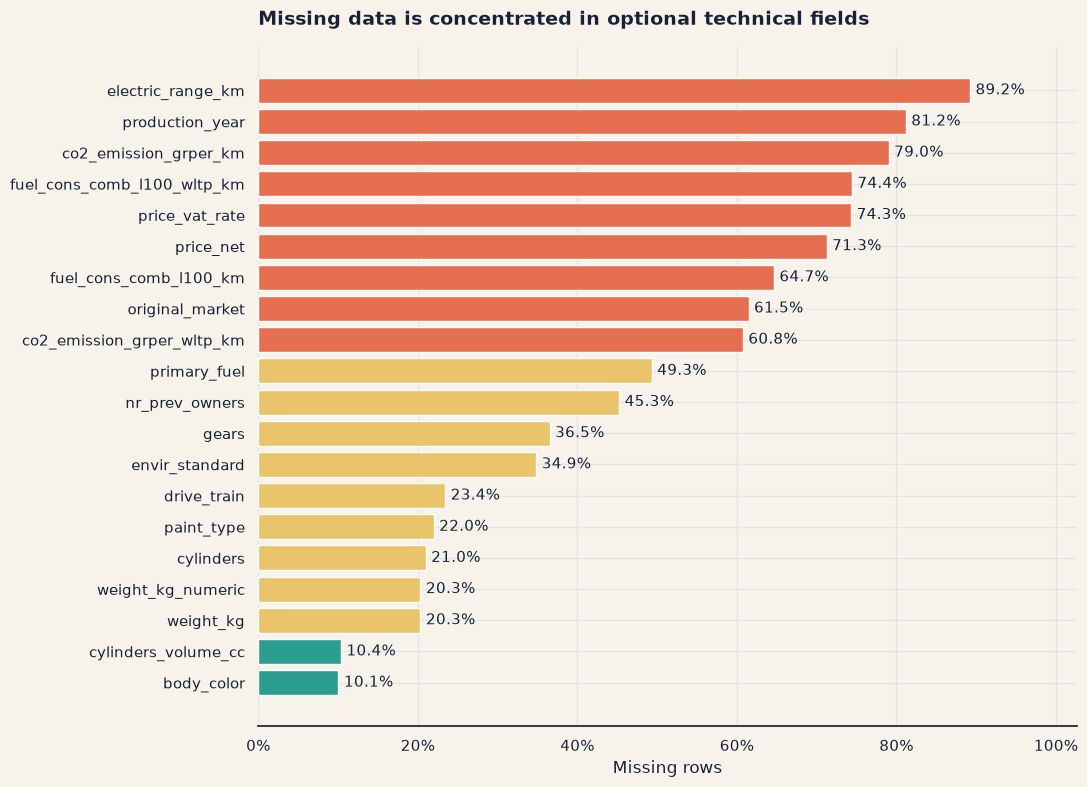

,missing_percentage,missing_count
electric_range_km,89.23%,"105,637"
production_year,81.19%,"96,110"
co2_emission_grper_km,79.04%,"93,571"
fuel_cons_comb_l100_wltp_km,74.43%,"88,112"
price_vat_rate,74.34%,"88,003"
price_net,71.27%,"84,366"
fuel_cons_comb_l100_km,64.65%,"76,538"
original_market,61.47%,"72,766"
co2_emission_grper_wltp_km,60.76%,"71,927"
primary_fuel,49.34%,"58,409"


In [4]:
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .rename("missing_percentage")
    .to_frame()
    .assign(missing_count=df.isna().sum())
    .sort_values("missing_percentage", ascending=False)
)

plot_missing = missing_summary.query("missing_percentage > 0").head(20).sort_values(
    "missing_percentage"
)

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(
    plot_missing.index,
    plot_missing["missing_percentage"],
    color=[
        COLORS["coral"] if value >= 50 else COLORS["gold"] if value >= 20 else COLORS["teal"]
        for value in plot_missing["missing_percentage"]
    ],
)
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in plot_missing["missing_percentage"]], padding=4)
ax.set_title("Missing data is concentrated in optional technical fields", loc="left", pad=16)
ax.set_xlabel("Missing rows")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlim(0, min(105, max(10, plot_missing["missing_percentage"].max() * 1.15)))
ax.spines[["top", "right", "left"]].set_visible(False)
finish_figure(fig, "01_missingness.png")

display(missing_summary.head(15).style.format({"missing_percentage": "{:.2f}%", "missing_count": "{:,.0f}"}))


### Data-quality interpretation

Missingness is not automatically a reason to discard a variable. For electric range and
fuel-consumption fields, absence can be structurally related to powertrain type. Preserve
that information with missing-value indicators during modeling. Entirely empty fields can
be dropped immediately because they carry no signal.


## 4. Target variable: vehicle price


,price
count,"€118,382"
mean,"€57,516"
std,"€109,986"
min,€1
1%,"€2,000"
5%,"€7,800"
25%,"€23,990"
50%,"€39,980"
75%,"€69,950"
95%,"€152,959"


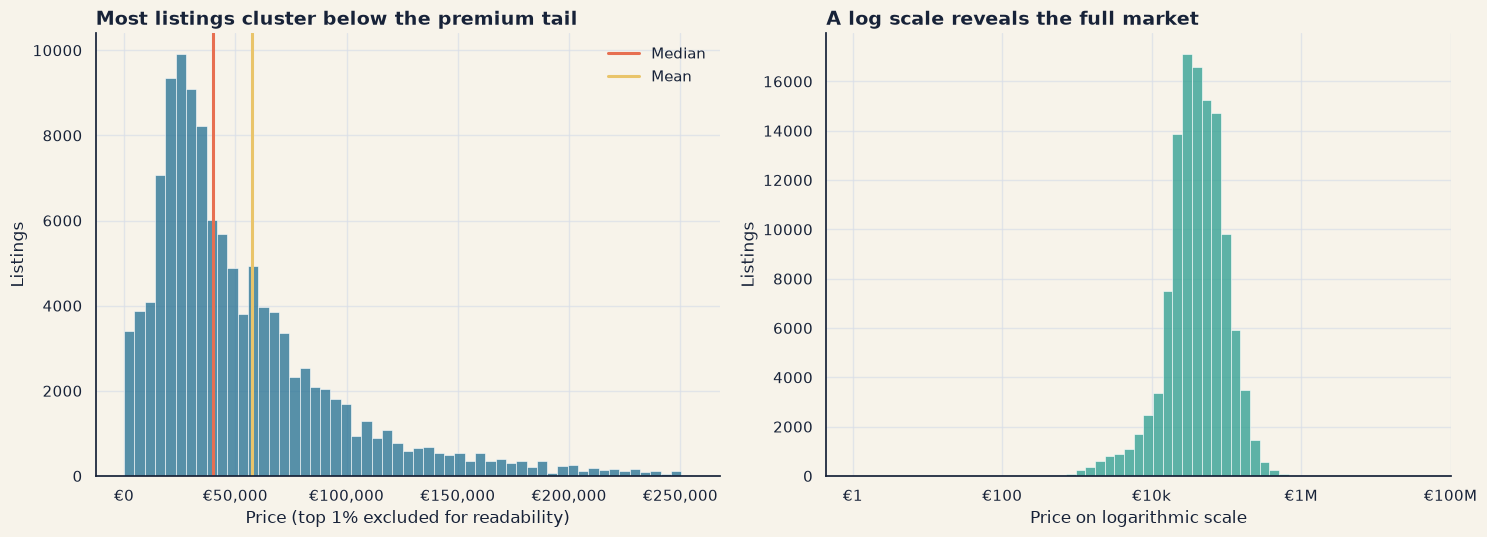

In [5]:
valid_price = df.loc[df["price"].gt(0), "price"].dropna()
price_cap_99 = valid_price.quantile(0.99)
price_cap_995 = valid_price.quantile(0.995)
price_plot = valid_price[valid_price <= price_cap_99]

price_summary = valid_price.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("price")
display(price_summary.style.format("€{:,.0f}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.histplot(price_plot, bins=55, color=COLORS["blue"], edgecolor="white", linewidth=0.4, ax=axes[0])
axes[0].axvline(valid_price.median(), color=COLORS["coral"], linewidth=2.2, label="Median")
axes[0].axvline(valid_price.mean(), color=COLORS["gold"], linewidth=2.2, label="Mean")
axes[0].set_title("Most listings cluster below the premium tail", loc="left")
axes[0].set_xlabel("Price (top 1% excluded for readability)")
axes[0].set_ylabel("Listings")
axes[0].xaxis.set_major_formatter(currency)
axes[0].legend(frameon=False)

sns.histplot(np.log10(valid_price), bins=55, color=COLORS["teal"], edgecolor="white", linewidth=0.4, ax=axes[1])
log_min = int(np.floor(np.log10(valid_price.min())))
log_max = int(np.ceil(np.log10(valid_price.max())))
log_ticks = np.unique(np.linspace(log_min, log_max, 5).round().astype(int))


def compact_euro(value: float) -> str:
    if value >= 1_000_000:
        return f"€{value / 1_000_000:g}M"
    if value >= 1_000:
        return f"€{value / 1_000:g}k"
    return f"€{value:g}"


axes[1].set_xticks(log_ticks)
axes[1].set_xticklabels([compact_euro(10 ** tick) for tick in log_ticks])
axes[1].set_title("A log scale reveals the full market", loc="left")
axes[1].set_xlabel("Price on logarithmic scale")
axes[1].set_ylabel("Listings")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

finish_figure(fig, "02_price_distribution.png")


The target is right-skewed: a relatively small luxury and specialty segment
extends far beyond the central market. Report MAE in currency units, but consider training
or evaluating an additional model on `log1p(price)` so expensive listings do not dominate
the loss function.


## 5. Brand composition and price positioning


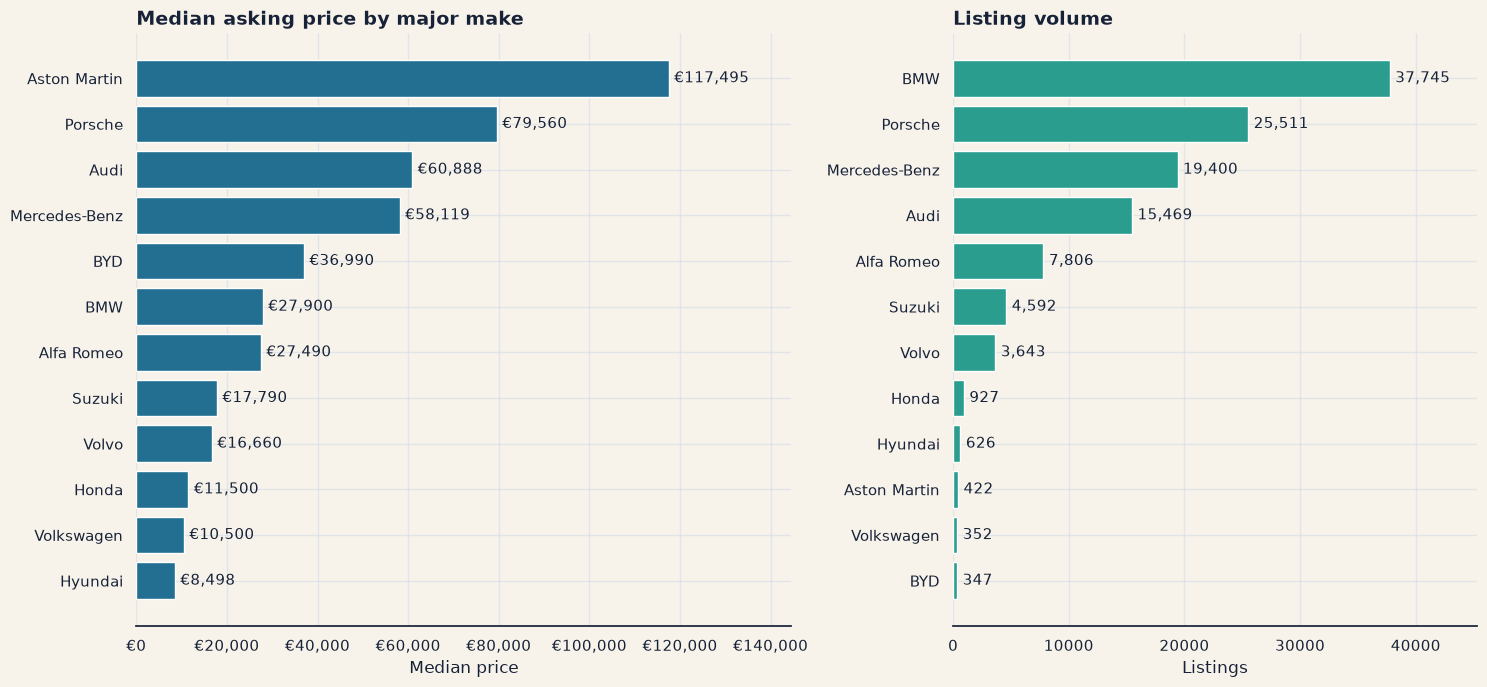

,listings,median_price,mean_price
make,,,
BMW,"37,745","€27,900","€34,471"
Porsche,"25,511","€79,560","€97,775"
Mercedes-Benz,"19,400","€58,119","€70,652"
Audi,"15,469","€60,888","€58,888"
Alfa Romeo,"7,806","€27,490","€26,728"
Suzuki,"4,592","€17,790","€16,746"
Volvo,"3,643","€16,660","€17,078"
Honda,927,"€11,500","€11,807"
Hyundai,626,"€8,498","€17,259"


In [6]:
top_makes = df["make"].value_counts().head(12).index
make_summary = (
    df.loc[df["make"].isin(top_makes) & df["price"].gt(0)]
    .groupby("make", observed=True)["price"]
    .agg(listings="size", median_price="median", mean_price="mean")
    .sort_values("median_price")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.25, 1]})

bars = axes[0].barh(make_summary.index, make_summary["median_price"], color=COLORS["blue"])
axes[0].bar_label(bars, labels=[f"€{value:,.0f}" for value in make_summary["median_price"]], padding=4)
axes[0].set_title("Median asking price by major make", loc="left")
axes[0].set_xlabel("Median price")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(currency)
axes[0].set_xlim(0, make_summary["median_price"].max() * 1.23)

count_summary = make_summary.sort_values("listings")
bars = axes[1].barh(count_summary.index, count_summary["listings"], color=COLORS["teal"])
axes[1].bar_label(bars, labels=[f"{value:,.0f}" for value in count_summary["listings"]], padding=4)
axes[1].set_title("Listing volume", loc="left")
axes[1].set_xlabel("Listings")
axes[1].set_ylabel("")
axes[1].set_xlim(0, count_summary["listings"].max() * 1.2)

for ax in axes:
    ax.spines[["top", "right", "left"]].set_visible(False)

finish_figure(fig, "03_make_positioning.png")
display(make_summary.sort_values("listings", ascending=False).style.format({"listings": "{:,.0f}", "median_price": "€{:,.0f}", "mean_price": "€{:,.0f}"}))


## 6. Mileage and depreciation


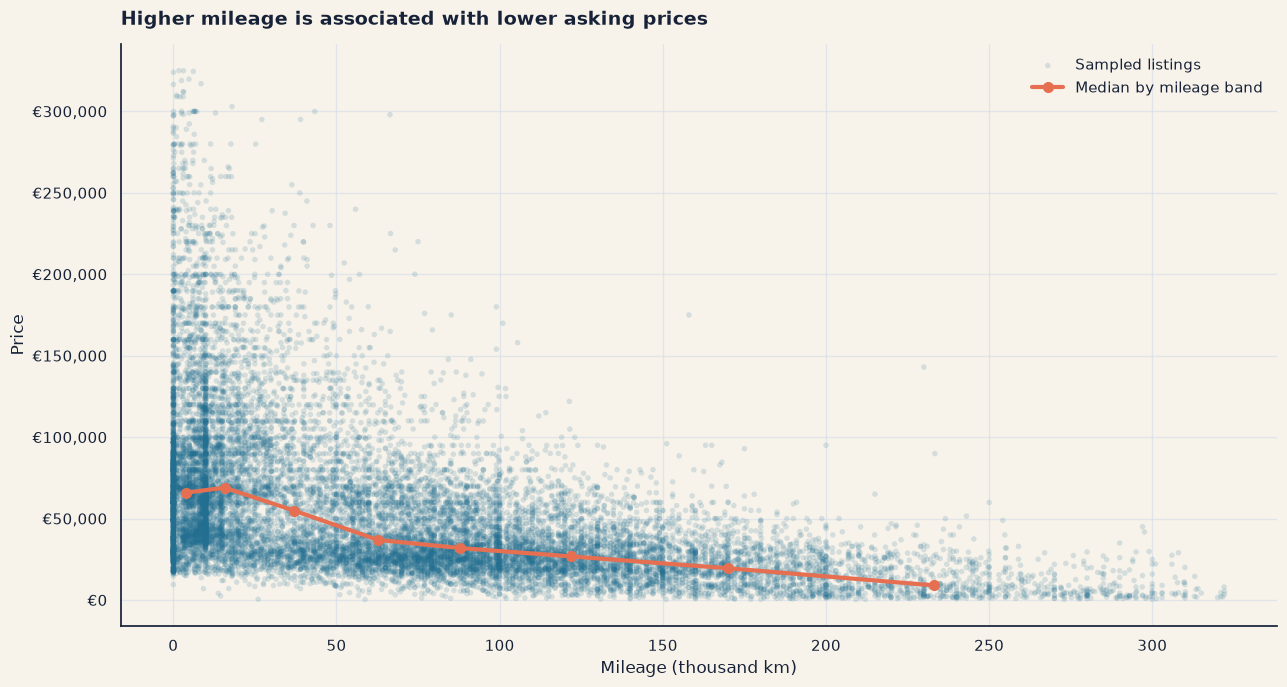

,median_mileage,median_price,listings
mileage_band,,,
"[0.0, 10000.0)","3,900 km","€65,900","28,681"
"[10000.0, 25000.0)","15,700 km","€68,970","13,613"
"[25000.0, 50000.0)","37,000 km","€54,900","12,729"
"[50000.0, 75000.0)","62,700 km","€36,899","13,446"
"[75000.0, 100000.0)","87,856 km","€31,900","14,353"
"[100000.0, 150000.0)","122,000 km","€26,750","18,495"
"[150000.0, 200000.0)","170,000 km","€19,490","9,491"
"[200000.0, inf)","233,000 km","€9,000","5,760"


In [7]:
mileage_price = df.loc[
    df["price"].between(1, price_cap_995)
    & df["mileage_km_raw"].between(0, df["mileage_km_raw"].quantile(0.995)),
    ["price", "mileage_km_raw", "vehicle_age"],
].dropna(subset=["price", "mileage_km_raw"])

scatter_sample = mileage_price.sample(min(18_000, len(mileage_price)), random_state=42)
mileage_price = mileage_price.assign(
    mileage_band=pd.cut(
        mileage_price["mileage_km_raw"],
        bins=[0, 10_000, 25_000, 50_000, 75_000, 100_000, 150_000, 200_000, np.inf],
        right=False,
    )
)
mileage_curve = (
    mileage_price.groupby("mileage_band", observed=True)
    .agg(median_mileage=("mileage_km_raw", "median"), median_price=("price", "median"), listings=("price", "size"))
    .query("listings >= 100")
)

fig, ax = plt.subplots(figsize=(13, 7))
ax.scatter(
    scatter_sample["mileage_km_raw"] / 1_000,
    scatter_sample["price"],
    s=16,
    alpha=0.16,
    color=COLORS["blue"],
    edgecolors="none",
    label="Sampled listings",
)
ax.plot(
    mileage_curve["median_mileage"] / 1_000,
    mileage_curve["median_price"],
    color=COLORS["coral"],
    marker="o",
    linewidth=3,
    markersize=7,
    label="Median by mileage band",
)
ax.set_title("Higher mileage is associated with lower asking prices", loc="left", pad=14)
ax.set_xlabel("Mileage (thousand km)")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(currency)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
finish_figure(fig, "04_price_vs_mileage.png")

display(mileage_curve.style.format({"median_mileage": "{:,.0f} km", "median_price": "€{:,.0f}", "listings": "{:,.0f}"}))


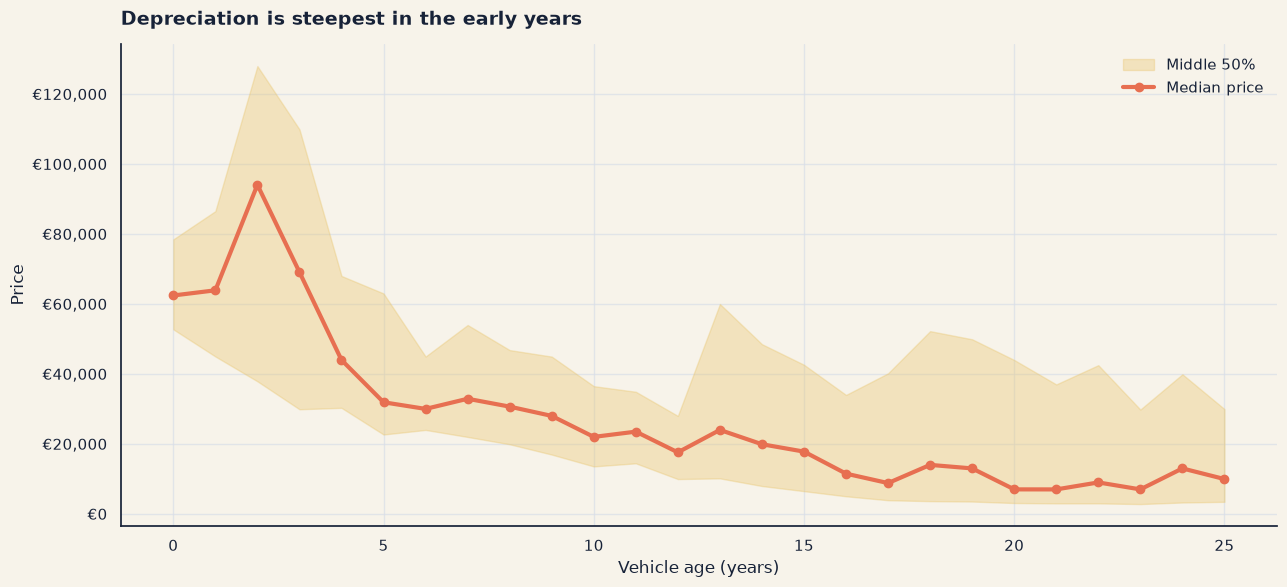

,median_price,q25,q75,listings
vehicle_age,,,,
0.000000,"€62,420","€52,747","€78,456",150
1.000000,"€63,900","€44,990","€86,525","32,031"
2.000000,"€94,050","€37,892","€127,980","7,458"
3.000000,"€69,100","€29,900","€109,900","3,970"
4.000000,"€43,990","€30,308","€68,000","9,206"
5.000000,"€31,900","€22,685","€62,999","7,703"
6.000000,"€29,999","€23,990","€44,965","15,416"
7.000000,"€32,900","€21,990","€53,980","6,711"
8.000000,"€30,650","€19,900","€46,812","6,036"


In [8]:
age_price = df.loc[
    df["vehicle_age"].between(0, 25) & df["price"].between(1, price_cap_995),
    ["vehicle_age", "price"],
].dropna()

age_curve = (
    age_price.groupby("vehicle_age", observed=True)["price"]
    .agg(median_price="median", q25=lambda values: values.quantile(0.25), q75=lambda values: values.quantile(0.75), listings="size")
    .query("listings >= 50")
)

fig, ax = plt.subplots(figsize=(13, 6))
ax.fill_between(age_curve.index, age_curve["q25"], age_curve["q75"], color=COLORS["gold"], alpha=0.35, label="Middle 50%")
ax.plot(age_curve.index, age_curve["median_price"], color=COLORS["coral"], marker="o", linewidth=3, label="Median price")
ax.set_title("Depreciation is steepest in the early years", loc="left", pad=14)
ax.set_xlabel("Vehicle age (years)")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(currency)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
finish_figure(fig, "05_depreciation_curve.png")

display(age_curve.head(15).style.format({"median_price": "€{:,.0f}", "q25": "€{:,.0f}", "q75": "€{:,.0f}", "listings": "{:,.0f}"}))


Mileage and age describe overlapping depreciation mechanisms. Their effect is
not necessarily linear, so tree-based models or engineered bands can capture the relationship
more naturally than a basic linear regression without transformations.


## 7. Market segments


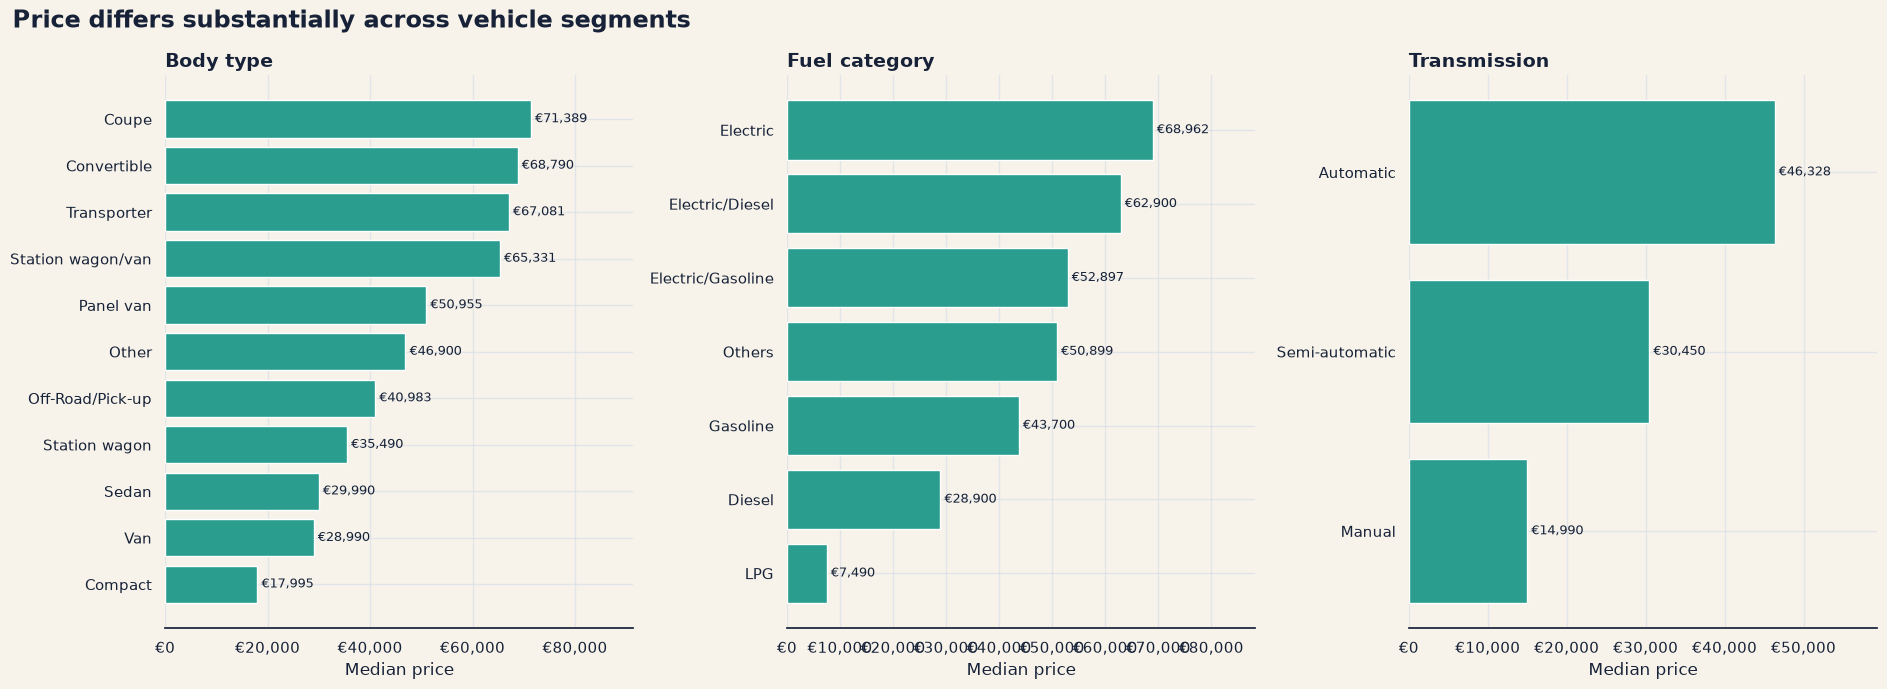

,listings,median_price
body_type,,
Compact,"4,968","€17,995"
Van,"2,747","€28,990"
Sedan,"24,753","€29,990"
Station wagon,"16,117","€35,490"
Off-Road/Pick-up,"45,470","€40,983"
Other,"1,231","€46,900"
Panel van,202,"€50,955"
Station wagon/van,135,"€65,331"
Transporter,"1,010","€67,081"


In [9]:
def category_price_summary(column: str, minimum_listings: int = 100) -> pd.DataFrame:
    return (
        df.loc[df["price"].gt(0) & df[column].notna()]
        .groupby(column, observed=True)["price"]
        .agg(listings="size", median_price="median")
        .query("listings >= @minimum_listings")
        .sort_values("median_price")
    )


segment_specs = [
    ("body_type", "Body type"),
    ("fuel_category", "Fuel category"),
    ("transmission", "Transmission"),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
segment_tables = {}

for ax, (column, title) in zip(axes, segment_specs):
    segment = category_price_summary(column)
    segment_tables[column] = segment
    bars = ax.barh(segment.index.astype(str), segment["median_price"], color=COLORS["teal"])
    ax.bar_label(bars, labels=[f"€{value:,.0f}" for value in segment["median_price"]], padding=3, fontsize=9)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Median price")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(currency)
    ax.set_xlim(0, segment["median_price"].max() * 1.28)
    ax.spines[["top", "right", "left"]].set_visible(False)

fig.suptitle("Price differs substantially across vehicle segments", x=0.01, ha="left", fontsize=17, fontweight="bold")
finish_figure(fig, "06_market_segments.png")

display(segment_tables["body_type"].style.format({"listings": "{:,.0f}", "median_price": "€{:,.0f}"}))


## 8. Geographic market differences


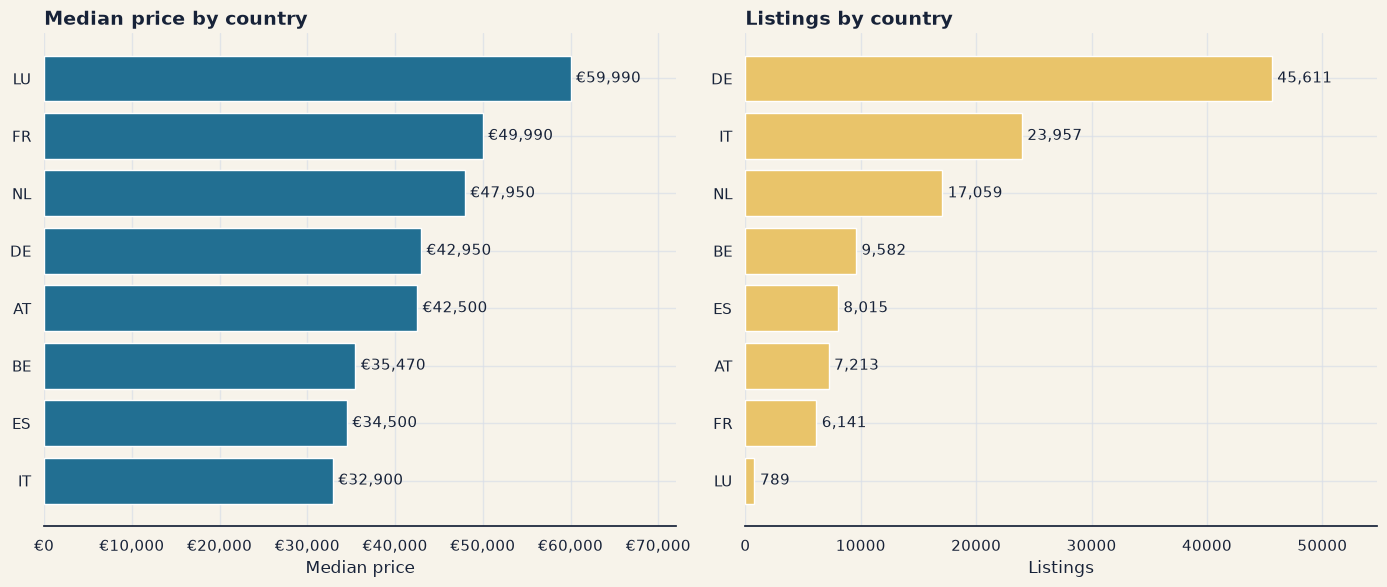

,listings,median_price
country_code,,
IT,"23,957","€32,900"
ES,"8,015","€34,500"
BE,"9,582","€35,470"
AT,"7,213","€42,500"
DE,"45,611","€42,950"
NL,"17,059","€47,950"
FR,"6,141","€49,990"
LU,789,"€59,990"


In [10]:
country_summary = (
    df.loc[df["price"].gt(0) & df["country_code"].notna()]
    .groupby("country_code", observed=True)["price"]
    .agg(listings="size", median_price="median")
    .query("listings >= 250")
    .sort_values("median_price")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bars = axes[0].barh(country_summary.index, country_summary["median_price"], color=COLORS["blue"])
axes[0].bar_label(bars, labels=[f"€{value:,.0f}" for value in country_summary["median_price"]], padding=4)
axes[0].set_title("Median price by country", loc="left")
axes[0].set_xlabel("Median price")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(currency)
axes[0].set_xlim(0, country_summary["median_price"].max() * 1.2)

country_volume = country_summary.sort_values("listings")
bars = axes[1].barh(country_volume.index, country_volume["listings"], color=COLORS["gold"])
axes[1].bar_label(bars, labels=[f"{value:,.0f}" for value in country_volume["listings"]], padding=4)
axes[1].set_title("Listings by country", loc="left")
axes[1].set_xlabel("Listings")
axes[1].set_ylabel("")
axes[1].set_xlim(0, country_volume["listings"].max() * 1.2)

for ax in axes:
    ax.spines[["top", "right", "left"]].set_visible(False)

finish_figure(fig, "07_country_comparison.png")
display(country_summary.style.format({"listings": "{:,.0f}", "median_price": "€{:,.0f}"}))


## 9. Taxation and like-for-like country comparison

The dataset includes partial tax information, but it does not contain every national
registration tax, import duty, subsidy, income level, or cost-of-living measure. The
following analysis therefore separates what is directly observed from what remains
unexplained.

Country price differences should be interpreted as a combination of taxation, market
composition, purchasing power, seller behavior, and other country-specific factors.


In [11]:
tax_columns = [
    "country_code",
    "price",
    "price_net",
    "price_vat_rate",
    "price_tax_deductible",
    "price_currency",
    "original_market",
]

tax_field_summary = pd.DataFrame(
    {
        "dtype": df[tax_columns].dtypes.astype(str),
        "non_missing_count": df[tax_columns].notna().sum(),
        "missing_count": df[tax_columns].isna().sum(),
        "missing_percentage": df[tax_columns].isna().mean().mul(100),
        "unique_values": df[tax_columns].nunique(dropna=True),
    }
)

display(
    tax_field_summary.style.format(
        {
            "non_missing_count": "{:,.0f}",
            "missing_count": "{:,.0f}",
            "missing_percentage": "{:.2f}%",
            "unique_values": "{:,.0f}",
        }
    )
)

print("Observed VAT-rate values:")
display(df["price_vat_rate"].value_counts(dropna=False).head(12).to_frame("listings"))


,dtype,non_missing_count,missing_count,missing_percentage,unique_values
country_code,str,"118,367",15,0.01%,8
price,float64,"118,382",0,0.00%,"16,476"
price_net,float64,"34,016","84,366",71.27%,"14,414"
price_vat_rate,float64,"30,379","88,003",74.34%,10
price_tax_deductible,bool,"118,382",0,0.00%,2
price_currency,str,"118,382",0,0.00%,1
original_market,str,"45,616","72,766",61.47%,33


Observed VAT-rate values:


,listings
price_vat_rate,
NaN,88003
19.0,23411
21.0,2559
20.0,2506
22.0,973
0.0,679
17.0,129
1.1,116
0.1,4


In [12]:
country_tax_summary = (
    df.groupby("country_code", observed=True)
    .agg(
        listings=("price", "size"),
        median_gross_price=("price", "median"),
        median_net_price=("price_net", "median"),
        median_vat_rate=("price_vat_rate", "median"),
        net_price_coverage=("price_net", lambda values: values.notna().mean()),
        vat_rate_coverage=("price_vat_rate", lambda values: values.notna().mean()),
        tax_deductible_share=("price_tax_deductible", "mean"),
    )
    .sort_values("listings", ascending=False)
)

display(
    country_tax_summary.style.format(
        {
            "listings": "{:,.0f}",
            "median_gross_price": "€{:,.0f}",
            "median_net_price": "€{:,.0f}",
            "median_vat_rate": "{:.1f}%",
            "net_price_coverage": "{:.1%}",
            "vat_rate_coverage": "{:.1%}",
            "tax_deductible_share": "{:.1%}",
        },
        na_rep="—",
    )
)


,listings,median_gross_price,median_net_price,median_vat_rate,net_price_coverage,vat_rate_coverage,tax_deductible_share
country_code,,,,,,,
DE,"45,611","€42,950","€44,454",19.0%,47.2%,51.9%,61.2%
IT,"23,957","€32,900","€25,856",22.0%,2.9%,5.8%,34.6%
NL,"17,059","€47,950","€51,610",21.0%,44.4%,1.9%,52.1%
BE,"9,582","€35,470","€36,360",21.0%,27.0%,23.7%,40.7%
ES,"8,015","€34,500",—,—,0.0%,0.0%,20.5%
AT,"7,213","€42,500","€54,972",20.0%,18.1%,34.5%,33.6%
FR,"6,141","€49,990","€56,555",19.0%,2.5%,1.5%,24.1%
LU,789,"€59,990","€54,692",17.0%,17.7%,17.6%,44.0%


Net prices and VAT rates are available mainly for a selected subset of dealer
listings. A country's median net price can therefore describe a different mix of vehicles
than its median gross price. These fields are useful for diagnostics, but missingness and
selection bias prevent them from fully explaining international price differences.


Comparison: BMW X3, registration years 2020–2022, mileage 30,000–70,000 km
Rows before the minimum-country-size filter: 583


,listings,median_gross_price,median_net_price,net_price_coverage,median_mileage,median_power_hp
country_code,,,,,,
ES,31,"€33,990",—,0.0%,"51,000 km",265 hp
IT,86,"€36,900","€37,900",3.5%,"56,020 km",190 hp
BE,59,"€38,490","€31,397",49.2%,"54,295 km",184 hp
DE,290,"€38,774","€33,605",52.1%,"49,879 km",286 hp
AT,20,"€42,225","€31,958",20.0%,"49,494 km",187 hp
FR,27,"€44,499","€35,090",3.7%,"55,000 km",190 hp
NL,68,"€49,890","€41,307",45.6%,"51,696 km",292 hp


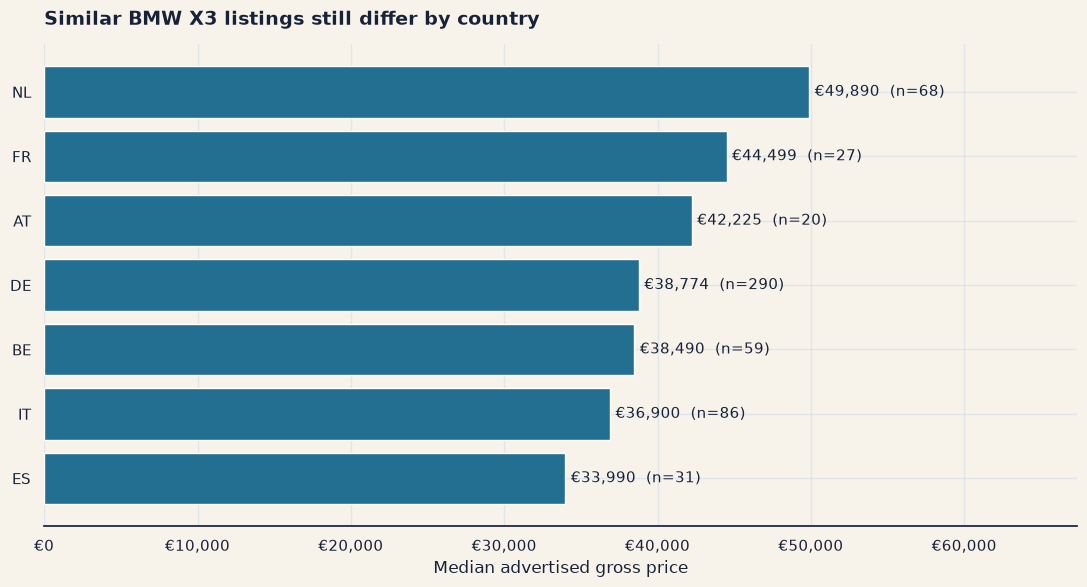

In [13]:
# Compare a narrower group of similar vehicles across countries.
selected_make = "BMW"
selected_model = "X3"
registration_year_range = (2020, 2022)
mileage_range = (30_000, 70_000)

comparison = df.loc[
    df["make"].eq(selected_make)
    & df["model"].eq(selected_model)
    & df["registration_year"].between(*registration_year_range)
    & df["mileage_km_raw"].between(*mileage_range)
    & df["price"].gt(0)
].copy()

comparison_summary = (
    comparison.groupby("country_code", observed=True)
    .agg(
        listings=("price", "size"),
        median_gross_price=("price", "median"),
        median_net_price=("price_net", "median"),
        net_price_coverage=("price_net", lambda values: values.notna().mean()),
        median_mileage=("mileage_km_raw", "median"),
        median_power_hp=("power_hp", "median"),
    )
    .query("listings >= 20")
    .sort_values("median_gross_price")
)

print(
    f"Comparison: {selected_make} {selected_model}, "
    f"registration years {registration_year_range[0]}–{registration_year_range[1]}, "
    f"mileage {mileage_range[0]:,}–{mileage_range[1]:,} km"
)
print(f"Rows before the minimum-country-size filter: {len(comparison):,}")

display(
    comparison_summary.style.format(
        {
            "listings": "{:,.0f}",
            "median_gross_price": "€{:,.0f}",
            "median_net_price": "€{:,.0f}",
            "net_price_coverage": "{:.1%}",
            "median_mileage": "{:,.0f} km",
            "median_power_hp": "{:,.0f} hp",
        },
        na_rep="—",
    )
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    comparison_summary.index,
    comparison_summary["median_gross_price"],
    color=COLORS["blue"],
)
ax.bar_label(
    bars,
    labels=[
        f"€{price:,.0f}  (n={count:,.0f})"
        for price, count in zip(
            comparison_summary["median_gross_price"],
            comparison_summary["listings"],
        )
    ],
    padding=4,
)
ax.set_title("Similar BMW X3 listings still differ by country", loc="left", pad=14)
ax.set_xlabel("Median advertised gross price")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(currency)
ax.set_xlim(0, comparison_summary["median_gross_price"].max() * 1.35)
ax.spines[["top", "right", "left"]].set_visible(False)
finish_figure(fig, "10_like_for_like_country_comparison.png")


### Interpretation limits

This filter reduces differences in make, model, age, and mileage, but it is not a controlled
tax experiment. Trim level, engine, power, equipment, vehicle condition, seller type, and
selection into the dataset can still differ by country. The remaining country gap is useful
predictive signal, but it cannot be attributed to taxation alone.


## 10. Numeric relationships and correlation


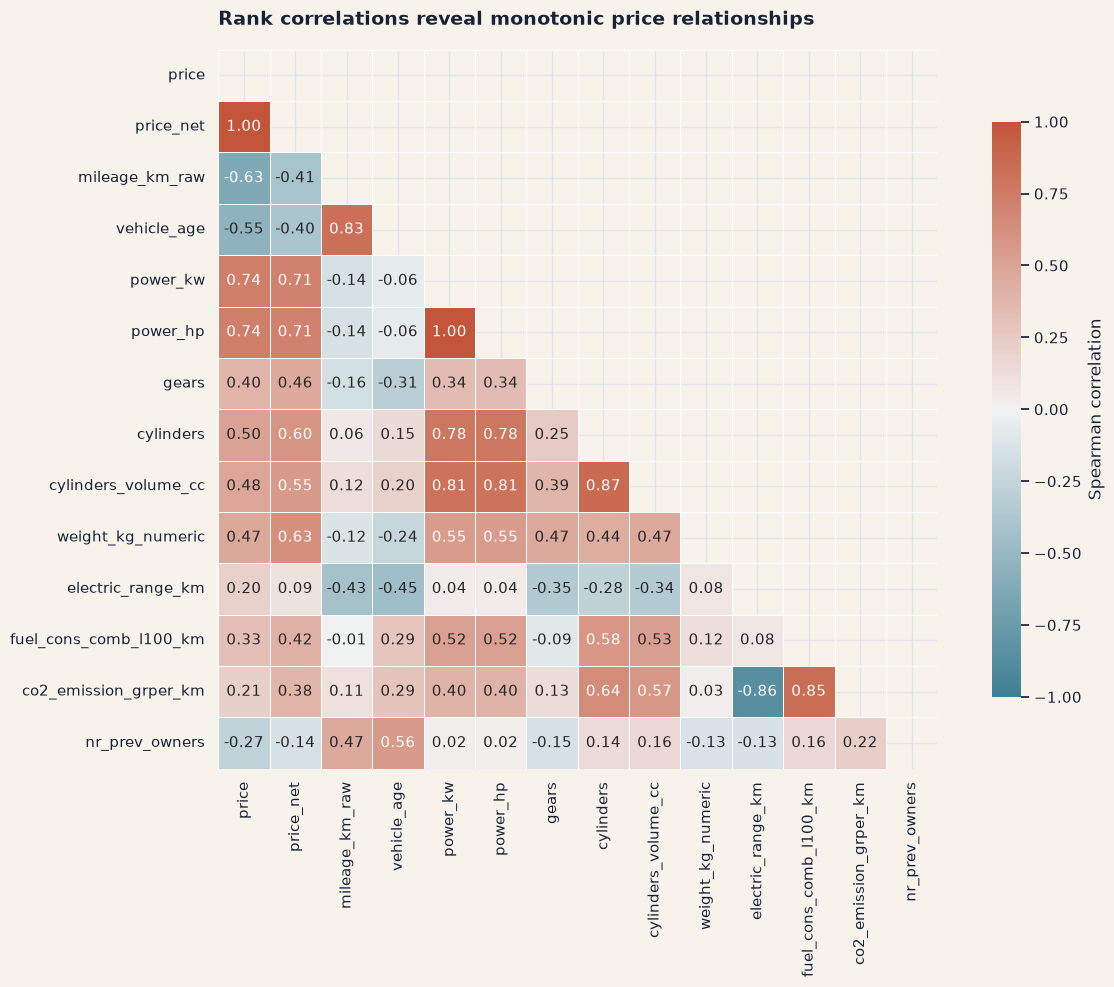

,spearman_with_price
price_net,+0.995
power_hp,+0.737
power_kw,+0.737
mileage_km_raw,-0.625
vehicle_age,-0.546
cylinders,+0.500
cylinders_volume_cc,+0.484
weight_kg_numeric,+0.472
gears,+0.398
fuel_cons_comb_l100_km,+0.328


In [14]:
correlation_columns = [
    "price",
    "price_net",
    "mileage_km_raw",
    "vehicle_age",
    "power_kw",
    "power_hp",
    "gears",
    "cylinders",
    "cylinders_volume_cc",
    "weight_kg_numeric",
    "electric_range_km",
    "fuel_cons_comb_l100_km",
    "co2_emission_grper_km",
    "nr_prev_owners",
]

corr = df[correlation_columns].corr(method="spearman", min_periods=250)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    square=True,
    cbar_kws={"label": "Spearman correlation", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Rank correlations reveal monotonic price relationships", loc="left", pad=18)
finish_figure(fig, "08_correlation_heatmap.png")

price_correlations = corr["price"].drop("price").sort_values(key=abs, ascending=False).to_frame("spearman_with_price")
display(price_correlations.style.format("{:+.3f}"))


### Important leakage warning

`price_net` is generally derived from the advertised price and tax treatment. It is not an
independent vehicle characteristic and should be excluded from the predictive feature set.
Similarly, any field calculated directly from price must be removed before training.


## 11. Outlier diagnostics


,min,p01,p25,median,p75,p99,max
price,1.0,"2,000.0","23,990.0","39,980.0","69,950.0","255,000.0","13,500,000.0"
mileage_km_raw,0.0,1.0,"10,000.0","56,400.0","111,231.8","287,148.7","2,570,000.0"
power_hp,1.0,83.0,162.0,231.0,367.0,650.0,"11,033.0"
cylinders_volume_cc,0.0,598.6,"1,950.0","1,997.0","2,993.0","4,806.0","99,999.0"
weight_kg_numeric,1.0,963.0,"1,550.0","1,815.0","2,135.0","2,900.0","93,000.0"
vehicle_age,0.0,1.0,1.0,5.0,8.0,25.0,71.0


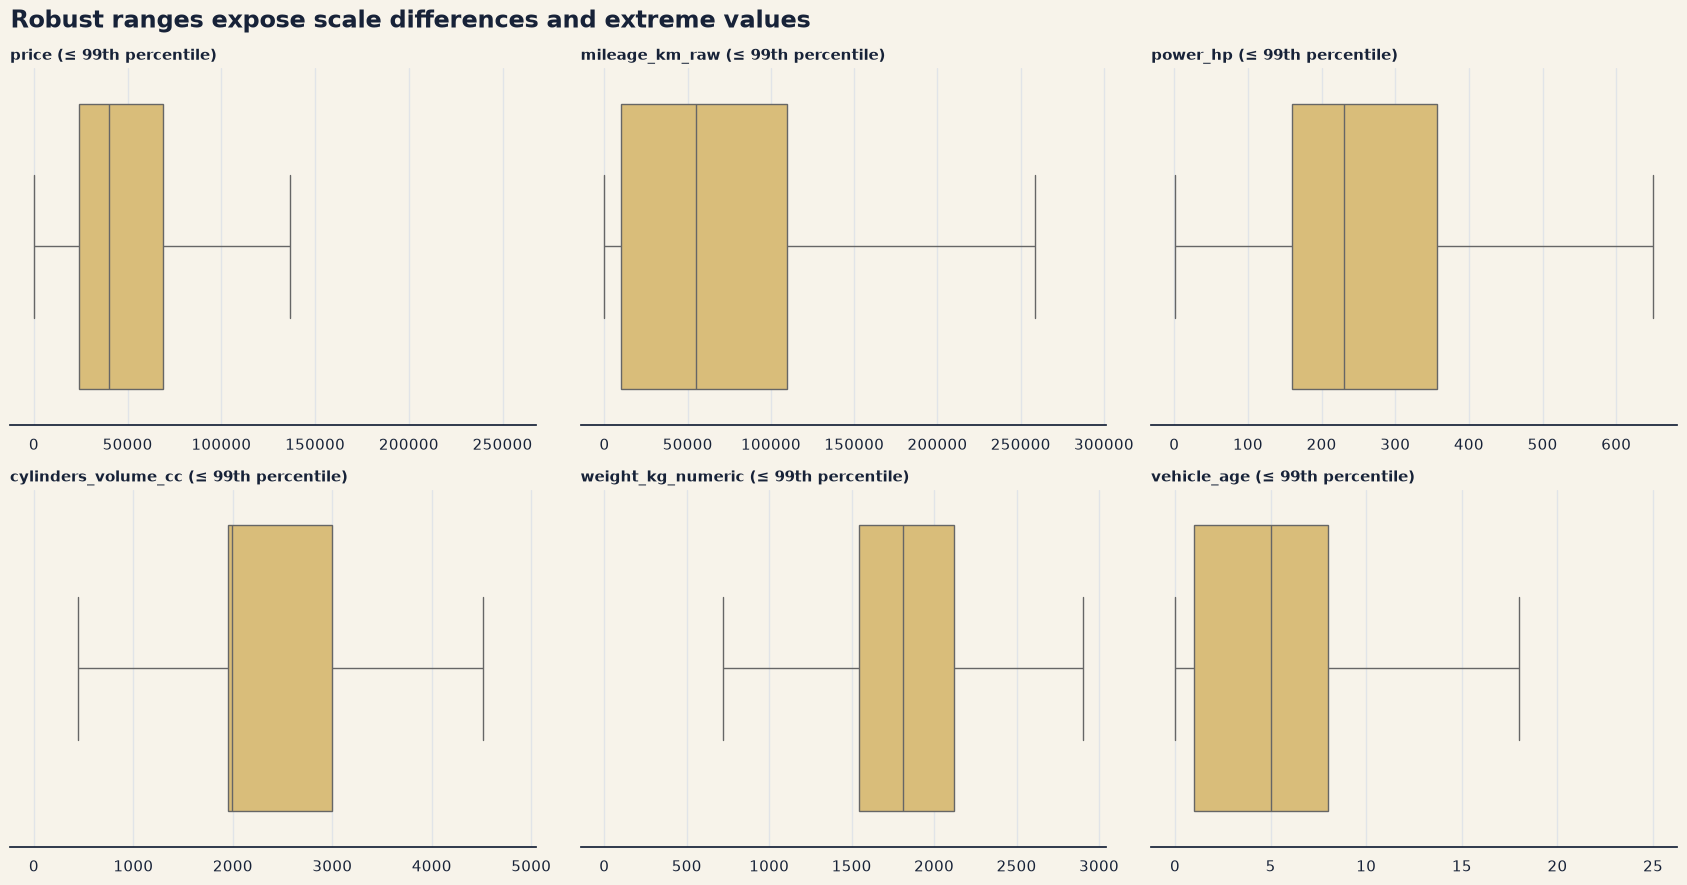

In [15]:
outlier_columns = [
    "price",
    "mileage_km_raw",
    "power_hp",
    "cylinders_volume_cc",
    "weight_kg_numeric",
    "vehicle_age",
]

outlier_summary = df[outlier_columns].quantile([0.00, 0.01, 0.25, 0.50, 0.75, 0.99, 1.00]).T
outlier_summary.columns = ["min", "p01", "p25", "median", "p75", "p99", "max"]
display(outlier_summary.style.format("{:,.1f}"))

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, column in zip(axes.flat, outlier_columns):
    values = df[column].dropna()
    upper = values.quantile(0.99)
    sns.boxplot(x=values[values <= upper], color=COLORS["gold"], fliersize=0, ax=ax)
    ax.set_title(f"{column} (≤ 99th percentile)", loc="left", fontsize=11)
    ax.set_xlabel("")
    ax.spines[["top", "right", "left"]].set_visible(False)

fig.suptitle("Robust ranges expose scale differences and extreme values", x=0.01, ha="left", fontsize=17, fontweight="bold")
finish_figure(fig, "09_outlier_diagnostics.png")


## 12. EDA conclusions and modeling decisions

### Strong first-model features

- Vehicle age, mileage, make, model, body type, power, transmission, fuel category,
  drivetrain, country, and seller type.
- Missing-value indicators for fields whose absence may be informative.
- Log-transformed or robustly capped versions of highly skewed numeric variables.

### Remove or postpone

- Drop the four verified empty columns from the project-wide feature list.
- Exclude identifiers such as `id` and direct price derivatives such as `price_net`.
- Postpone `description` and equipment-list fields until a clean tabular baseline exists.
  They require dedicated text or multi-label feature engineering.

### Validation design

- Split the data before fitting imputers, encoders, scalers, or target-based features.
- Use MAE as the main interpretable metric and RMSE as a secondary tail-sensitive metric.
- Compare against a simple median-price baseline before testing advanced models.
- Consider grouped or time-aware validation if multiple listings can represent the same car
  or if registration/listing timing affects the deployment scenario.

### Recommended next notebook

Create a preprocessing and baseline-model notebook using a scikit-learn `Pipeline` and
`ColumnTransformer`. Start with a median baseline, then compare HistGradientBoosting,
Random Forest, and a gradient-boosting implementation if available.
